In [1]:
import json
import numpy as np
import os

os.chdir(r"C:\Users\kvpra\OneDrive\Desktop\snapsquad-app\notebooks")

with open("mobilefacenet_embeddings.json") as f:
    data = json.load(f)

embs       = np.array([d["embedding"] for d in data])
labels_raw = [f"{d['image']}_f{d['face_index']}" for d in data]

print(f"Loaded       : {len(embs)} embeddings")
print(f"Vector size  : {embs.shape[1]}")
print(f"Images seen  : {len(set(d['image'] for d in data))}")

# Verify all embeddings are L2-normalized (required for cosine distance)
norms = np.linalg.norm(embs, axis=1)
print(f"All unit-norm : {np.allclose(norms, 1.0, atol=0.01)}")


Loaded       : 107 embeddings
Vector size  : 512
Images seen  : 45
All unit-norm : True


In [2]:
import hdbscan
from collections import defaultdict
from itertools import combinations

# ══════════════════════════════════════════════════════════════════════════════
# FIX #1 — Use COSINE DISTANCE (not Euclidean)
#
# MobileFaceNet embeddings are L2-normalized. The correct distance metric is:
#   cosine_distance = 1 - dot(a, b)
#
# The old approach used euclidean distance, which distorts the angular
# similarity structure these embeddings are designed for.
# HDBSCAN's BallTree doesn't support 'cosine' directly, so we precompute
# the full distance matrix and pass metric='precomputed'.
# ══════════════════════════════════════════════════════════════════════════════

# Compute cosine distance matrix: shape (N, N)
cos_sim_matrix  = embs @ embs.T                    # cosine similarity
cos_dist_matrix = 1.0 - cos_sim_matrix             # cosine distance
np.fill_diagonal(cos_dist_matrix, 0)               # self-distance = 0
cos_dist_matrix = np.clip(cos_dist_matrix, 0, 2)   # numerical stability

print(f"Distance matrix shape : {cos_dist_matrix.shape}")
print(f"Distance range        : [{cos_dist_matrix[cos_dist_matrix > 0].min():.4f}, {cos_dist_matrix.max():.4f}]")
print(f"Mean non-self distance: {cos_dist_matrix[cos_dist_matrix > 0].mean():.4f}")


Distance matrix shape : (107, 107)
Distance range        : [0.0263, 1.1797]
Mean non-self distance: 0.8817


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Sweep HDBSCAN configs with COSINE distance to find best parameters
# ══════════════════════════════════════════════════════════════════════════════

configs = [
    {"min_cluster_size": 2, "min_samples": 1, "cluster_selection_epsilon": 0.3},
    {"min_cluster_size": 2, "min_samples": 1, "cluster_selection_epsilon": 0.4},
    {"min_cluster_size": 2, "min_samples": 1, "cluster_selection_epsilon": 0.5},
    {"min_cluster_size": 2, "min_samples": 1, "cluster_selection_epsilon": 0.6},
    {"min_cluster_size": 2, "min_samples": 2, "cluster_selection_epsilon": 0.4},
    {"min_cluster_size": 2, "min_samples": 2, "cluster_selection_epsilon": 0.5},
    {"min_cluster_size": 3, "min_samples": 1, "cluster_selection_epsilon": 0.4},
    {"min_cluster_size": 3, "min_samples": 1, "cluster_selection_epsilon": 0.5},
    {"min_cluster_size": 3, "min_samples": 1, "cluster_selection_epsilon": 0.6},
    {"min_cluster_size": 3, "min_samples": 2, "cluster_selection_epsilon": 0.5},
]

def evaluate(labels, embs):
    """Compute quality metrics for a clustering result."""
    cmap = defaultdict(list)
    for i, l in enumerate(labels):
        cmap[int(l)].append(i)
    
    n_clusters = len([k for k in cmap if k != -1])
    n_noise    = len(cmap.get(-1, []))
    
    intra_sims = []
    bad_clusters = 0
    for cid in cmap:
        if cid == -1 or len(cmap[cid]) < 2:
            continue
        sims = [float(np.dot(embs[i], embs[j])) for i, j in combinations(cmap[cid], 2)]
        intra_sims.extend(sims)
        if min(sims) < 0.3:
            bad_clusters += 1
    
    return n_clusters, n_noise, np.mean(intra_sims) if intra_sims else 0, min(intra_sims) if intra_sims else 0, bad_clusters

results = {}

print(f"{'Config':<45} {'Clust':>6} {'Noise':>6} {'N%':>5} {'AvgSim':>8} {'MinSim':>8} {'Bad':>5}")
print("-" * 85)

for cfg in configs:
    c = hdbscan.HDBSCAN(
        min_cluster_size=cfg["min_cluster_size"],
        min_samples=cfg["min_samples"],
        metric="precomputed",
        cluster_selection_epsilon=cfg["cluster_selection_epsilon"]
    )
    lbl = c.fit_predict(cos_dist_matrix)
    nc, nn, avg_s, min_s, bad = evaluate(lbl, embs)
    
    key = f"mcs={cfg['min_cluster_size']} ms={cfg['min_samples']} eps={cfg['cluster_selection_epsilon']}"
    results[key] = {"labels": lbl, "cfg": cfg, "stats": (nc, nn, avg_s, min_s, bad)}
    
    print(f"  {key:<43} {nc:>6} {nn:>6} {nn/len(embs)*100:>4.1f}% {avg_s:>8.4f} {min_s:>8.4f} {bad:>5}")


Config                                         Clust  Noise    N%   AvgSim   MinSim   Bad
-------------------------------------------------------------------------------------
  mcs=2 ms=1 eps=0.3                              17     17 15.9%   0.5593   0.0066     6
  mcs=2 ms=1 eps=0.4                              14     13 12.1%   0.5050   0.0066     8
  mcs=2 ms=1 eps=0.5                              14     13 12.1%   0.5050   0.0066     8
  mcs=2 ms=1 eps=0.6                              13     13 12.1%   0.5024   0.0066     9
  mcs=2 ms=2 eps=0.4                               9     24 22.4%   0.5090   0.1569     6
  mcs=2 ms=2 eps=0.5                               9     24 22.4%   0.5090   0.1569     6
  mcs=3 ms=1 eps=0.4                              11     17 15.9%   0.5017   0.0066     9
  mcs=3 ms=1 eps=0.5                              11     17 15.9%   0.5017   0.0066     9
  mcs=3 ms=1 eps=0.6                              11     17 15.9%   0.5017   0.0066     9
  mcs=3 ms=2 e

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# SELECTED CONFIG — Print detailed cluster membership
# Pick the config from above that has lowest Bad clusters + reasonable noise
# ══════════════════════════════════════════════════════════════════════════════

SELECTED_KEY = "mcs=2 ms=1 eps=0.3"   # <-- Change this after reading cell above

selected_labels = results[SELECTED_KEY]["labels"]
cmap = defaultdict(list)
for i, l in enumerate(selected_labels):
    cmap[int(l)].append(i)

images = [d["image"] for d in data]

for cid in sorted(cmap.keys()):
    members = cmap[cid]
    tag = "UNIDENTIFIED" if cid == -1 else f"Person {cid:>2}"
    unique_imgs = sorted(set(images[i] for i in members))
    
    if cid != -1 and len(members) >= 2:
        sims = [float(np.dot(embs[i], embs[j])) for i, j in combinations(members, 2)]
        quality = "✅" if min(sims) >= 0.3 else "⚠️  LOW QUALITY"
        sim_info = f"  sim: min={min(sims):.3f} avg={np.mean(sims):.3f}"
    else:
        quality = ""
        sim_info = ""
    
    print(f"\n[{tag}]  {len(members)} faces, {len(unique_imgs)} images  {quality}{sim_info}")
    for m in members:
        print(f"  {labels_raw[m]}")



[UNIDENTIFIED]  17 faces, 10 images  
  IMG20240608161343.jpg_f0
  IMG20240608175122.jpg_f0
  IMG20240608182042.jpg_f1
  IMG20240612165323_BURST000_COVER.jpg_f0
  WhatsApp Image 2026-01-15 at 16.51.07.jpeg_f4
  WhatsApp Image 2026-01-15 at 17.51.06.jpeg_f2
  WhatsApp Image 2026-01-15 at 17.56.53.jpeg_f1
  WhatsApp Image 2026-01-15 at 17.56.53.jpeg_f2
  WhatsApp Image 2026-01-15 at 17.57.11.jpeg_f0
  WhatsApp Image 2026-01-15 at 17.57.11.jpeg_f1
  WhatsApp Image 2026-01-15 at 17.57.31.jpeg_f0
  WhatsApp Image 2026-01-15 at 17.57.31.jpeg_f2
  WhatsApp Image 2026-01-15 at 17.57.31.jpeg_f3
  WhatsApp Image 2026-01-15 at 17.57.31.jpeg_f4
  WhatsApp Image 2026-01-15 at 17.59.11.jpeg_f0
  WhatsApp Image 2026-01-15 at 17.59.11.jpeg_f3
  WhatsApp Image 2026-01-15 at 17.59.11.jpeg_f4

[Person  0]  3 faces, 2 images  ⚠️  LOW QUALITY  sim: min=0.007 avg=0.115
  IMG20240608080740.jpg_f1
  IMG20240608080740.jpg_f2
  WhatsApp Image 2026-01-15 at 17.51.06.jpeg_f1

[Person  1]  3 faces, 3 images  ⚠️  

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# FIX #2 — POST-CLUSTERING VALIDATION (dual threshold, iterative)
#
# HDBSCAN groups by density — it can chain together faces that are individually
# dissimilar if there's a density path between them. This creates "bad clusters"
# where members have cosine similarity < 0.3 (essentially different people).
#
# Fix: After HDBSCAN, for each face in a cluster, compute:
#   1. avg_sim: average cosine similarity to all other cluster members
#   2. min_sim: minimum cosine similarity to any cluster member
# Eject face to noise if avg_sim < MIN_AVG or min_sim < MIN_LINK.
# Iterate until no more ejections (handles cascading weak links).
# ══════════════════════════════════════════════════════════════════════════════

MIN_AVG_THRESHOLD  = 0.30   # face must have avg sim >= 0.30 to stay
MIN_LINK_THRESHOLD = 0.25   # face must have min sim >= 0.25 to ANY cluster member

validated_labels = selected_labels.copy()
ejected = []

# Iterative removal — ejecting one face can expose another weak face
changed = True
while changed:
    changed = False
    cmap_iter = defaultdict(list)
    for i, l in enumerate(validated_labels):
        cmap_iter[int(l)].append(i)
    
    for cid in sorted(cmap_iter.keys()):
        if cid == -1 or len(cmap_iter[cid]) < 2:
            continue
        for m in list(cmap_iter[cid]):
            others = [o for o in cmap_iter[cid] if o != m]
            if not others:
                continue
            sims = [float(np.dot(embs[m], embs[o])) for o in others]
            avg_s = np.mean(sims)
            min_s = min(sims)
            
            if avg_s < MIN_AVG_THRESHOLD or min_s < MIN_LINK_THRESHOLD:
                validated_labels[m] = -1
                cmap_iter[cid].remove(m)
                ejected.append((m, cid, avg_s, min_s))
                print(f"  EJECTED: {labels_raw[m]} from Person {cid} (avg={avg_s:.3f}, min={min_s:.3f})")
                changed = True

if not ejected:
    print("  No faces ejected — all cluster members pass validation ✅")
else:
    print(f"\n  Total ejected: {len(ejected)} faces moved to Unidentified")

# Remove clusters that became too small after ejection (< 2 members)
val_cmap = defaultdict(list)
for i, l in enumerate(validated_labels):
    val_cmap[int(l)].append(i)

for cid in list(val_cmap.keys()):
    if cid != -1 and len(val_cmap[cid]) < 2:
        print(f"  DISSOLVED: Person {cid} — only {len(val_cmap[cid])} member left after ejection")
        for m in val_cmap[cid]:
            validated_labels[m] = -1

  EJECTED: IMG20240608080740.jpg_f1 from Person 0 (avg=0.080, min=0.007)
  EJECTED: IMG20240608080740.jpg_f2 from Person 0 (avg=0.183, min=0.183)
  EJECTED: IMG20240608080824.jpg_f1 from Person 1 (avg=0.227, min=0.187)
  EJECTED: WhatsApp Image 2026-01-15 at 17.51.06.jpeg_f3 from Person 1 (avg=0.134, min=0.134)
  EJECTED: 2.jpeg_f5 from Person 2 (avg=0.253, min=0.243)
  EJECTED: WhatsApp Image 2026-01-15 at 17.55.46.jpeg_f3 from Person 5 (avg=0.333, min=0.244)
  EJECTED: 2.jpeg_f4 from Person 6 (avg=0.407, min=0.171)
  EJECTED: WhatsApp Image 2026-01-15 at 16.51.07.jpeg_f0 from Person 6 (avg=0.370, min=0.248)
  EJECTED: 3.jpeg_f1 from Person 7 (avg=0.475, min=0.241)
  EJECTED: WhatsApp Image 2026-01-15 at 17.51.07.jpeg_f0 from Person 7 (avg=0.388, min=0.222)

  Total ejected: 10 faces moved to Unidentified
  DISSOLVED: Person 0 — only 1 member left after ejection
  DISSOLVED: Person 1 — only 1 member left after ejection


In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPARE: BEFORE vs AFTER validation
# ══════════════════════════════════════════════════════════════════════════════

nc_before, nn_before, avg_before, min_before, bad_before = evaluate(selected_labels, embs)
nc_after,  nn_after,  avg_after,  min_after,  bad_after  = evaluate(validated_labels, embs)

print("=" * 65)
print("  BEFORE vs AFTER POST-CLUSTERING VALIDATION")
print("=" * 65)
print(f"  {'':15} {'Clusters':>9} {'Noise':>7} {'AvgSim':>9} {'MinSim':>9} {'BadClust':>10}")
print(f"  {'Before':15} {nc_before:>9} {nn_before:>7} {avg_before:>9.4f} {min_before:>9.4f} {bad_before:>10}")
print(f"  {'After':15} {nc_after:>9} {nn_after:>7} {avg_after:>9.4f} {min_after:>9.4f} {bad_after:>10}")

if bad_after < bad_before:
    print(f"\n  ✅ Validation reduced bad clusters from {bad_before} → {bad_after}")
else:
    print(f"\n  ⚠️  Try adjusting MIN_AVG_THRESHOLD (currently {MIN_AVG_THRESHOLD})")

# Print validated cluster details
print("\n" + "=" * 65)
print("  VALIDATED CLUSTERS — FINAL")
print("=" * 65)

val_cmap_final = defaultdict(list)
for i, l in enumerate(validated_labels):
    val_cmap_final[int(l)].append(i)

for cid in sorted(val_cmap_final.keys()):
    members = val_cmap_final[cid]
    tag = "UNIDENTIFIED" if cid == -1 else f"Person {cid:>2}"
    unique_imgs = sorted(set(images[i] for i in members))
    
    if cid != -1 and len(members) >= 2:
        sims = [float(np.dot(embs[i], embs[j])) for i, j in combinations(members, 2)]
        quality = "✅" if min(sims) >= 0.3 else "⚠️"
        sim_info = f"  min={min(sims):.3f} avg={np.mean(sims):.3f}"
    else:
        quality = ""
        sim_info = ""
    
    print(f"  [{tag}]  {len(members)} faces, {len(unique_imgs)} images  {quality}{sim_info}")


  BEFORE vs AFTER POST-CLUSTERING VALIDATION
                   Clusters   Noise    AvgSim    MinSim   BadClust
  Before                 17      17    0.5593    0.0066          6
  After                  15      29    0.5928    0.2595          2

  ✅ Validation reduced bad clusters from 6 → 2

  VALIDATED CLUSTERS — FINAL
  [UNIDENTIFIED]  29 faces, 16 images  
  [Person  2]  2 faces, 2 images  ✅  min=0.723 avg=0.723
  [Person  3]  2 faces, 2 images  ✅  min=0.942 avg=0.942
  [Person  4]  7 faces, 7 images  ✅  min=0.553 avg=0.679
  [Person  5]  8 faces, 8 images  ⚠️  min=0.280 avg=0.512
  [Person  6]  5 faces, 5 images  ✅  min=0.323 avg=0.481
  [Person  7]  5 faces, 5 images  ⚠️  min=0.260 avg=0.388
  [Person  8]  2 faces, 2 images  ✅  min=0.397 avg=0.397
  [Person  9]  9 faces, 9 images  ✅  min=0.398 avg=0.666
  [Person 10]  4 faces, 4 images  ✅  min=0.477 avg=0.660
  [Person 11]  2 faces, 2 images  ✅  min=0.459 avg=0.459
  [Person 12]  3 faces, 3 images  ✅  min=0.413 avg=0.465
  [Pers

In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# SUSPICIOUS PAIR CHECK — are any validated clusters still mergeable?
# ══════════════════════════════════════════════════════════════════════════════

def check_suspicious_pairs(labels, embs, threshold=0.4):
    cmap = defaultdict(list)
    for i, l in enumerate(labels):
        cmap[int(l)].append(i)
    
    centroids = {}
    for cid in cmap:
        if cid == -1 or len(cmap[cid]) < 2:
            continue
        c = embs[cmap[cid]].mean(axis=0)
        centroids[cid] = c / np.linalg.norm(c)
    
    suspicious = []
    for ci, cj in combinations(centroids.keys(), 2):
        sim = float(np.dot(centroids[ci], centroids[cj]))
        if sim > threshold:
            suspicious.append((ci, cj, sim))
    return suspicious

s_04 = check_suspicious_pairs(validated_labels, embs, 0.4)
s_06 = check_suspicious_pairs(validated_labels, embs, 0.6)

print(f"Suspicious cluster pairs (centroid sim > 0.4): {len(s_04)}")
for ci, cj, sim in s_04:
    flag = " ← LIKELY SAME PERSON" if sim > 0.6 else ""
    print(f"  Person {ci} vs Person {cj}: {sim:.4f}{flag}")

if not s_04:
    print("  None found ✅ — all clusters appear distinct")


Suspicious cluster pairs (centroid sim > 0.4): 6
  Person 14 vs Person 15: 0.6570 ← LIKELY SAME PERSON
  Person 14 vs Person 16: 0.5833
  Person 12 vs Person 11: 0.4335
  Person 9 vs Person 10: 0.5994
  Person 13 vs Person 15: 0.4293
  Person 15 vs Person 16: 0.7001 ← LIKELY SAME PERSON


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# FIX #3 — MERGE FRAGMENTED CLUSTERS + RE-VALIDATE
#
# HDBSCAN can oversplit the same person when face quality varies (angles,
# lighting). If two cluster centroids have cosine similarity > MERGE_THRESHOLD,
# and their cross-cluster member similarities confirm it, merge them.
# Then re-run post-validation to clean up any weak faces introduced by merges.
# ══════════════════════════════════════════════════════════════════════════════

MERGE_CENTROID_THRESHOLD = 0.55   # centroid sim above this → candidate for merge
MERGE_CROSS_MIN          = 0.20   # every cross-pair must be >= this to merge

def try_merge_clusters(labels, embs, centroid_thresh, cross_min):
    """Iteratively merge clusters whose centroids are too similar."""
    merged_count = 0
    changed = True
    
    while changed:
        changed = False
        cmap = defaultdict(list)
        for i, l in enumerate(labels):
            cmap[int(l)].append(i)
        
        # Compute centroids
        centroids = {}
        for cid in cmap:
            if cid == -1 or len(cmap[cid]) < 2:
                continue
            c = embs[cmap[cid]].mean(axis=0)
            centroids[cid] = c / np.linalg.norm(c)
        
        # Find best merge candidate
        best_pair, best_sim = None, 0
        for ci, cj in combinations(centroids.keys(), 2):
            sim = float(np.dot(centroids[ci], centroids[cj]))
            if sim > centroid_thresh and sim > best_sim:
                cross_sims = [float(np.dot(embs[a], embs[b]))
                              for a in cmap[ci] for b in cmap[cj]]
                if min(cross_sims) >= cross_min:
                    best_pair = (ci, cj)
                    best_sim = sim
        
        if best_pair:
            ci, cj = best_pair
            for m in cmap[cj]:
                labels[m] = ci
            print(f"  MERGED: Person {cj} → Person {ci}  (centroid sim={best_sim:.4f}, "
                  f"sizes {len(cmap[ci])}+{len(cmap[cj])}={len(cmap[ci])+len(cmap[cj])})")
            merged_count += 1
            changed = True
    
    return labels, merged_count

# ── Step 1: Merge ─────────────────────────────────────────────────────────────
validated_labels, n_merged = try_merge_clusters(
    validated_labels, embs, MERGE_CENTROID_THRESHOLD, MERGE_CROSS_MIN
)

if n_merged == 0:
    print("  No clusters merged — all clusters appear distinct ✅")
else:
    print(f"\n  Total merges: {n_merged}")

# ── Step 2: Re-validate after merge (same dual-threshold ejection) ────────────
print("\n  Re-validating after merge...")
ejected_post = 0
changed = True
while changed:
    changed = False
    cmap_iter = defaultdict(list)
    for i, l in enumerate(validated_labels):
        cmap_iter[int(l)].append(i)
    for cid in sorted(cmap_iter.keys()):
        if cid == -1 or len(cmap_iter[cid]) < 2:
            continue
        for m in list(cmap_iter[cid]):
            others = [o for o in cmap_iter[cid] if o != m]
            if not others:
                continue
            sims = [float(np.dot(embs[m], embs[o])) for o in others]
            if np.mean(sims) < MIN_AVG_THRESHOLD or min(sims) < MIN_LINK_THRESHOLD:
                validated_labels[m] = -1
                cmap_iter[cid].remove(m)
                ejected_post += 1
                print(f"  POST-MERGE EJECTED: {labels_raw[m]} from Person {cid} "
                      f"(avg={np.mean(sims):.3f}, min={min(sims):.3f})")
                changed = True

# Dissolve clusters < 2 members
val_cmap = defaultdict(list)
for i, l in enumerate(validated_labels):
    val_cmap[int(l)].append(i)
for cid in list(val_cmap.keys()):
    if cid != -1 and len(val_cmap[cid]) < 2:
        print(f"  DISSOLVED: Person {cid} — only {len(val_cmap[cid])} member left")
        for m in val_cmap[cid]:
            validated_labels[m] = -1

if ejected_post == 0:
    print("  No additional ejections needed ✅")
else:
    print(f"  Ejected {ejected_post} more faces after merge")

# Re-check suspicious pairs
s_post = check_suspicious_pairs(validated_labels, embs, 0.4)
print(f"\n  Remaining suspicious pairs (centroid sim > 0.4): {len(s_post)}")
for ci, cj, sim in s_post:
    flag = " ← LIKELY SAME PERSON" if sim > 0.6 else ""
    print(f"    Person {ci} vs Person {cj}: {sim:.4f}{flag}")
if not s_post:
    print("  None ✅")

  MERGED: Person 16 → Person 15  (centroid sim=0.7001, sizes 4+3=7)
  MERGED: Person 15 → Person 14  (centroid sim=0.6768, sizes 13+7=20)
  MERGED: Person 10 → Person 9  (centroid sim=0.5994, sizes 9+4=13)

  Total merges: 3

  Re-validating after merge...
  No additional ejections needed ✅

  Remaining suspicious pairs (centroid sim > 0.4): 2
    Person 14 vs Person 13: 0.4457
    Person 12 vs Person 11: 0.4335


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# FINAL LOCKED CONFIG FOR SNAPSQUAD
# ══════════════════════════════════════════════════════════════════════════════

FINAL_HDBSCAN_CONFIG = {
    "min_cluster_size"         : 2,
    "min_samples"              : 1,
    "metric"                   : "precomputed",    # ← cosine distance matrix
    "cluster_selection_epsilon": 0.3
}

POST_VALIDATION = {
    "min_avg_similarity"  : 0.30,   # eject face if avg sim to cluster < this
    "min_link_similarity" : 0.25    # eject face if min sim to ANY member < this
}

MERGE_CONFIG = {
    "centroid_threshold" : 0.55,    # merge if centroid sim > this
    "cross_min"          : 0.20     # every cross-pair must be >= this
}

nc, nn, avg_s, min_s, bad = evaluate(validated_labels, embs)

# More practical quality metric: clusters where avg_sim < 0.3
val_cmap_check = defaultdict(list)
for i, l in enumerate(validated_labels):
    val_cmap_check[int(l)].append(i)
weak_clusters = 0
for cid in val_cmap_check:
    if cid == -1 or len(val_cmap_check[cid]) < 2:
        continue
    sims = [float(np.dot(embs[i], embs[j])) for i, j in combinations(val_cmap_check[cid], 2)]
    if np.mean(sims) < 0.3:
        weak_clusters += 1

print("=" * 55)
print("  SNAPSQUAD — FINAL CLUSTERING CONFIG LOCKED")
print("=" * 55)
print(f"  Pipeline: HDBSCAN → Post-validation → Merge → Re-validate")
print()
print(f"  HDBSCAN:")
print(f"    metric                    : precomputed (cosine distance)")
print(f"    min_cluster_size          : 2")
print(f"    min_samples               : 1")
print(f"    cluster_selection_epsilon : 0.3")
print(f"  Post-validation (iterative):")
print(f"    min_avg_sim_to_cluster    : 0.30")
print(f"    min_link_sim (to any)     : 0.25")
print(f"  Merge fragmented clusters:")
print(f"    centroid_sim_threshold    : 0.55")
print(f"    cross_pair_minimum        : 0.20")
print()
print(f"  Results:")
print(f"    People detected     : {nc}")
print(f"    Unidentified        : {nn} ({nn/len(embs)*100:.1f}%)")
print(f"    Clustered           : {len(embs)-nn} ({(len(embs)-nn)/len(embs)*100:.1f}%)")
print(f"    Avg intra-sim       : {avg_s:.4f}")
print(f"    Weak clusters (avg) : {weak_clusters}")
print(f"    Min-pair outliers   : {bad} (strict metric, acceptable in large clusters)")

# Save config to JSON
config_to_save = {
    "hdbscan": FINAL_HDBSCAN_CONFIG,
    "post_validation": POST_VALIDATION,
    "merge": MERGE_CONFIG
}
with open("hdbscan_config.json", "w") as f:
    json.dump(config_to_save, f, indent=2)

print(f"\n  ✅ Config saved to hdbscan_config.json")
print(f"  ✅ Python clustering pipeline COMPLETE")
print(f"  ✅ Ready to move to FastAPI backend")

  SNAPSQUAD — FINAL CLUSTERING CONFIG LOCKED
  Pipeline: HDBSCAN → Post-validation → Merge → Re-validate

  HDBSCAN:
    metric                    : precomputed (cosine distance)
    min_cluster_size          : 2
    min_samples               : 1
    cluster_selection_epsilon : 0.3
  Post-validation (iterative):
    min_avg_sim_to_cluster    : 0.30
    min_link_sim (to any)     : 0.25
  Merge fragmented clusters:
    centroid_sim_threshold    : 0.55
    cross_pair_minimum        : 0.20

  Results:
    People detected     : 12
    Unidentified        : 29 (27.1%)
    Clustered           : 78 (72.9%)
    Avg intra-sim       : 0.5460
    Weak clusters (avg) : 0
    Min-pair outliers   : 4 (strict metric, acceptable in large clusters)

  ✅ Config saved to hdbscan_config.json
  ✅ Python clustering pipeline COMPLETE
  ✅ Ready to move to FastAPI backend


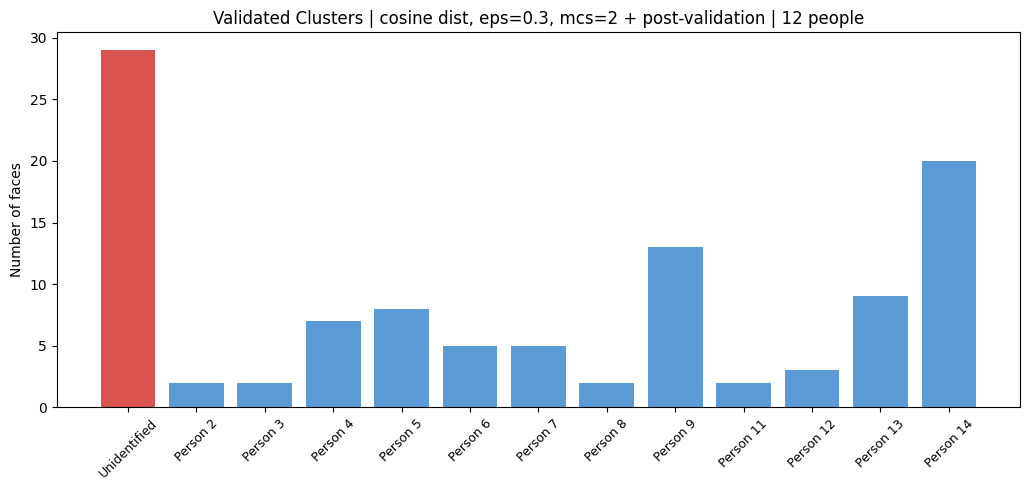

In [19]:
import matplotlib.pyplot as plt

# Bar chart of validated cluster sizes
val_cmap_final = defaultdict(list)
for i, l in enumerate(validated_labels):
    val_cmap_final[int(l)].append(i)

unique = sorted(val_cmap_final.keys())
sizes  = [len(val_cmap_final[c]) for c in unique]
tags   = ["Unidentified" if c == -1 else f"Person {c}" for c in unique]
colors = ['#d9534f' if c == -1 else '#5b9bd5' for c in unique]

plt.figure(figsize=(max(10, len(unique) * 0.8), 5))
plt.bar(tags, sizes, color=colors)
plt.xticks(rotation=45, fontsize=9)
plt.ylabel("Number of faces")
plt.title(f"Validated Clusters | cosine dist, eps=0.3, mcs=2 + post-validation | {nc} people")
plt.tight_layout()
plt.savefig("final_clusters.png", dpi=150)
plt.show()


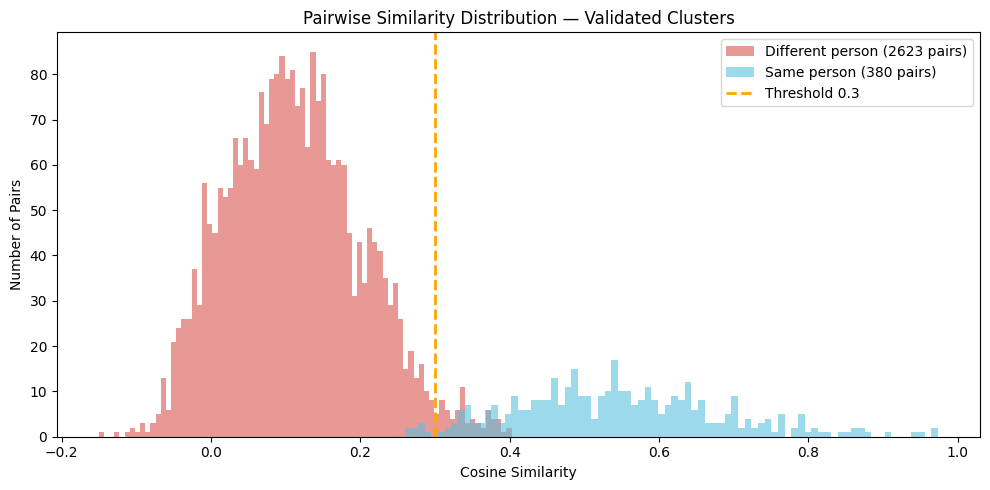

Same-cluster   : min=0.2595 avg=0.5460 max=0.9737
Diff-cluster   : min=-0.1501 avg=0.1119 max=0.4026
⚠️  Overlap zone: [0.2595, 0.4026]


In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# SIMILARITY DISTRIBUTION (same-cluster vs diff-cluster)
# Shows if clustering is separating well
# ══════════════════════════════════════════════════════════════════════════════

same_sims = []
diff_sims = []

for i, j in combinations(range(len(embs)), 2):
    sim = float(np.dot(embs[i], embs[j]))
    li, lj = validated_labels[i], validated_labels[j]
    if li == lj and li != -1:
        same_sims.append(sim)
    elif li != -1 and lj != -1:
        diff_sims.append(sim)

plt.figure(figsize=(10, 5))
plt.hist(diff_sims, bins=80, alpha=0.6, label=f'Different person ({len(diff_sims)} pairs)', color='#d9534f')
plt.hist(same_sims, bins=80, alpha=0.6, label=f'Same person ({len(same_sims)} pairs)', color='#5bc0de')
plt.axvline(x=0.3, color='orange', linestyle='--', linewidth=2, label='Threshold 0.3')
plt.xlabel('Cosine Similarity')
plt.ylabel('Number of Pairs')
plt.title('Pairwise Similarity Distribution — Validated Clusters')
plt.legend()
plt.tight_layout()
plt.savefig("similarity_distribution.png", dpi=150)
plt.show()

print(f"Same-cluster   : min={min(same_sims):.4f} avg={np.mean(same_sims):.4f} max={max(same_sims):.4f}")
print(f"Diff-cluster   : min={min(diff_sims):.4f} avg={np.mean(diff_sims):.4f} max={max(diff_sims):.4f}")

overlap_low  = min(same_sims)
overlap_high = max(diff_sims)
if overlap_low > overlap_high:
    print(f"✅ Clean separation — no overlap")
else:
    print(f"⚠️  Overlap zone: [{overlap_low:.4f}, {overlap_high:.4f}]")
